# When Models Get It Spectacularly Wrong

**Live demo: training a neural network on the simplest possible task**

We're going to:
1. Look at the MNIST dataset — 70,000 handwritten digits
2. Train a neural network to classify them
3. Get 99%+ accuracy
4. Then look at the 1% it gets wrong — and see how *confident* it is

This is the simplest image classification task in machine learning. Clean data. Human labels. No ambiguity. If a model can fail here, imagine what happens with language.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
})

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: False


## 1.5 What "Curve Fitting" Actually Means

Before we get to MNIST, let's build an intuition for what neural networks actually do. At their core, they're fitting curves through data — finding a mathematical function that maps inputs to outputs. Here's what that looks like with simple 2D data.

/var/folders/y0/xl1fbc7s2qxdsnj21f88m5q80000gn/T/ipykernel_27749/847122671.py:23: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_data, y_data, degree)


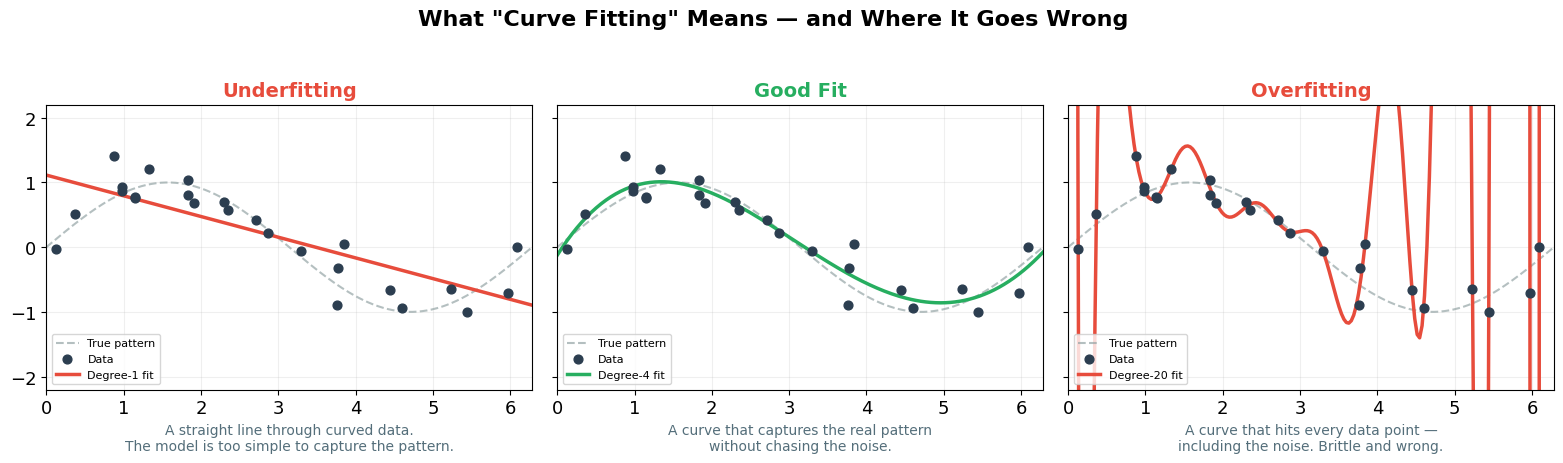

Left:   Too simple — misses the pattern entirely.
Middle: Just right — captures the real signal, ignores the noise.
Right:  Too complex — memorises the noise, fails on new data.

A neural network is doing this in millions of dimensions.


In [2]:
# Generate noisy data from a known function
np.random.seed(42)
x_data = np.sort(np.random.uniform(0, 2 * np.pi, 25))
y_true_fn = np.sin(x_data)
y_data = y_true_fn + np.random.normal(0, 0.25, len(x_data))

# Smooth x range for plotting fits
x_smooth = np.linspace(0, 2 * np.pi, 200)

# Three fits: underfit, good fit, overfit
fits = [
    (1,  'Underfitting',  'A straight line through curved data.\nThe model is too simple to capture the pattern.'),
    (4,  'Good Fit',      'A curve that captures the real pattern\nwithout chasing the noise.'),
    (20, 'Overfitting',   'A curve that hits every data point —\nincluding the noise. Brittle and wrong.'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
fig.suptitle('What "Curve Fitting" Means — and Where It Goes Wrong',
             fontsize=16, fontweight='bold', y=1.03)

for ax, (degree, title, caption) in zip(axes, fits):
    # Fit polynomial
    coeffs = np.polyfit(x_data, y_data, degree)
    y_fit = np.polyval(coeffs, x_smooth)

    # Plot true function
    ax.plot(x_smooth, np.sin(x_smooth), '--', color='#95a5a6', linewidth=1.5,
            label='True pattern', alpha=0.7)
    # Plot data points
    ax.scatter(x_data, y_data, color='#2c3e50', s=40, zorder=5, label='Data')
    # Plot fit
    colour = '#e74c3c' if degree != 4 else '#27ae60'
    ax.plot(x_smooth, y_fit, '-', color=colour, linewidth=2.5, label=f'Degree-{degree} fit')

    ax.set_title(title, fontsize=14, fontweight='bold', color=colour)
    ax.set_xlabel(caption, fontsize=10, color='#546e7a')
    ax.set_ylim(-2.2, 2.2)
    ax.set_xlim(0, 2 * np.pi)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/curve_fitting.png', dpi=150, bbox_inches='tight')
plt.show()

print("Left:   Too simple — misses the pattern entirely.")
print("Middle: Just right — captures the real signal, ignores the noise.")
print("Right:  Too complex — memorises the noise, fails on new data.")
print("\nA neural network is doing this in millions of dimensions.")

## 2. The Data: 70,000 Handwritten Digits

MNIST has been around since 1998. Each image is 28×28 pixels, greyscale, centred. It's as clean and simple as image data gets.

In [3]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training images: {x_train.shape[0]:,}")
print(f"Test images:     {x_test.shape[0]:,}")
print(f"Image size:      {x_train.shape[1]}×{x_train.shape[2]} pixels")
print(f"Pixel range:     {x_train.min()} to {x_train.max()}")

Training images: 60,000
Test images:     10,000
Image size:      28×28 pixels
Pixel range:     0 to 255


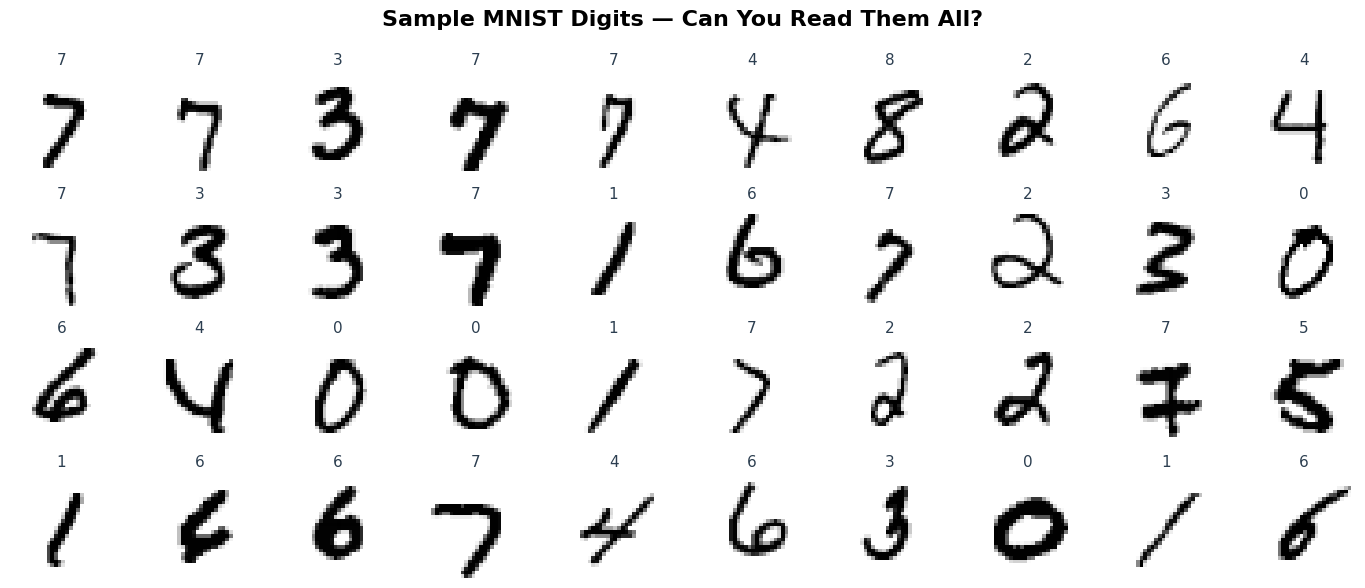


Notice the variety in handwriting styles — some of these are hard even for humans.


In [4]:
# Show a sample grid — this is what the model has to work with
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
fig.suptitle("Sample MNIST Digits — Can You Read Them All?", fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(x_train))
    ax.imshow(x_train[idx], cmap='gray_r')
    ax.set_title(f"{y_train[idx]}", fontsize=11, color='#2c3e50')
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/mnist_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNotice the variety in handwriting styles — some of these are hard even for humans.")

## 3. Build a Simple Neural Network

Nothing fancy. A small convolutional neural network — the standard approach for image classification. This is well-understood, textbook stuff.

In [5]:
# Normalise pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Add channel dimension (28, 28) -> (28, 28, 1)
x_train_norm = x_train_norm[..., np.newaxis]
x_test_norm = x_test_norm[..., np.newaxis]

# Build model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')  # 10 digits, softmax = confidence scores
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/Users/chrispedder/Documents/Projects/SSBM-Lectures/AI_use/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train It

This should take about a minute. Watch the accuracy climb — it gets very good, very fast.

In [6]:
history = model.fit(
    x_train_norm, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5


  1/422 ━━━━━━━━━━━━━━━━━━━━ 10:09 1s/step - accuracy: 0.0938 - loss: 2.3180

  3/422 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.1957 - loss: 2.2878

  5/422 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.2454 - loss: 2.2637

  7/422 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.2839 - loss: 2.2353

...

411/422 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9898 - loss: 0.0328

414/422 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9898 - loss: 0.0328

417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9898 - loss: 0.0328

420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9898 - loss: 0.0328

422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9899 - loss: 0.0328 - val_accuracy: 0.9900 - val_loss: 0.0331


In [7]:
# Final test accuracy
test_loss, test_acc = model.evaluate(x_test_norm, y_test, verbose=0)
n_correct = int(test_acc * len(y_test))
n_wrong = len(y_test) - n_correct

print(f"\n{'='*50}")
print(f"  Test accuracy: {test_acc:.2%}")
print(f"  Got {n_correct:,} out of {len(y_test):,} correct")
print(f"  Got {n_wrong} wrong")
print(f"{'='*50}")
print(f"\n99%+ accuracy. Impressive, right?")
print(f"But let's look at those {n_wrong} failures...")


  Test accuracy: 99.01%
  Got 9,901 out of 10,000 correct
  Got 99 wrong

99%+ accuracy. Impressive, right?
But let's look at those 99 failures...


## 5. Finding the Failures

99% accuracy sounds great. But what about the other 1%?

Let's find every image the model gets wrong — and see how *confident* it was.

In [8]:
# Get predictions and confidence scores for all test images
predictions = model.predict(x_test_norm, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
confidence_scores = np.max(predictions, axis=1)

# Find wrong predictions
wrong_mask = predicted_labels != y_test
wrong_indices = np.where(wrong_mask)[0]
wrong_confidences = confidence_scores[wrong_indices]

# Sort by confidence (most confident mistakes first)
confidence_order = np.argsort(-wrong_confidences)
wrong_indices_sorted = wrong_indices[confidence_order]

print(f"Found {len(wrong_indices)} mistakes out of {len(y_test):,} test images")
print(f"\nMost confident mistake: {wrong_confidences.max():.1%} confidence — and WRONG")
print(f"Average confidence on mistakes: {wrong_confidences.mean():.1%}")
print(f"Average confidence on correct answers: {confidence_scores[~wrong_mask].mean():.1%}")

Found 99 mistakes out of 10,000 test images

Most confident mistake: 99.9% confidence — and WRONG
Average confidence on mistakes: 72.7%
Average confidence on correct answers: 99.3%


## 6. The Punchline: Confident and Wrong

Here are the model's **most confident mistakes** — cases where it was almost certain, and completely wrong.

For each one, you'll see:
- The actual handwritten digit (obvious to any human)
- What the model predicted
- How confident it was across all 10 possible digits

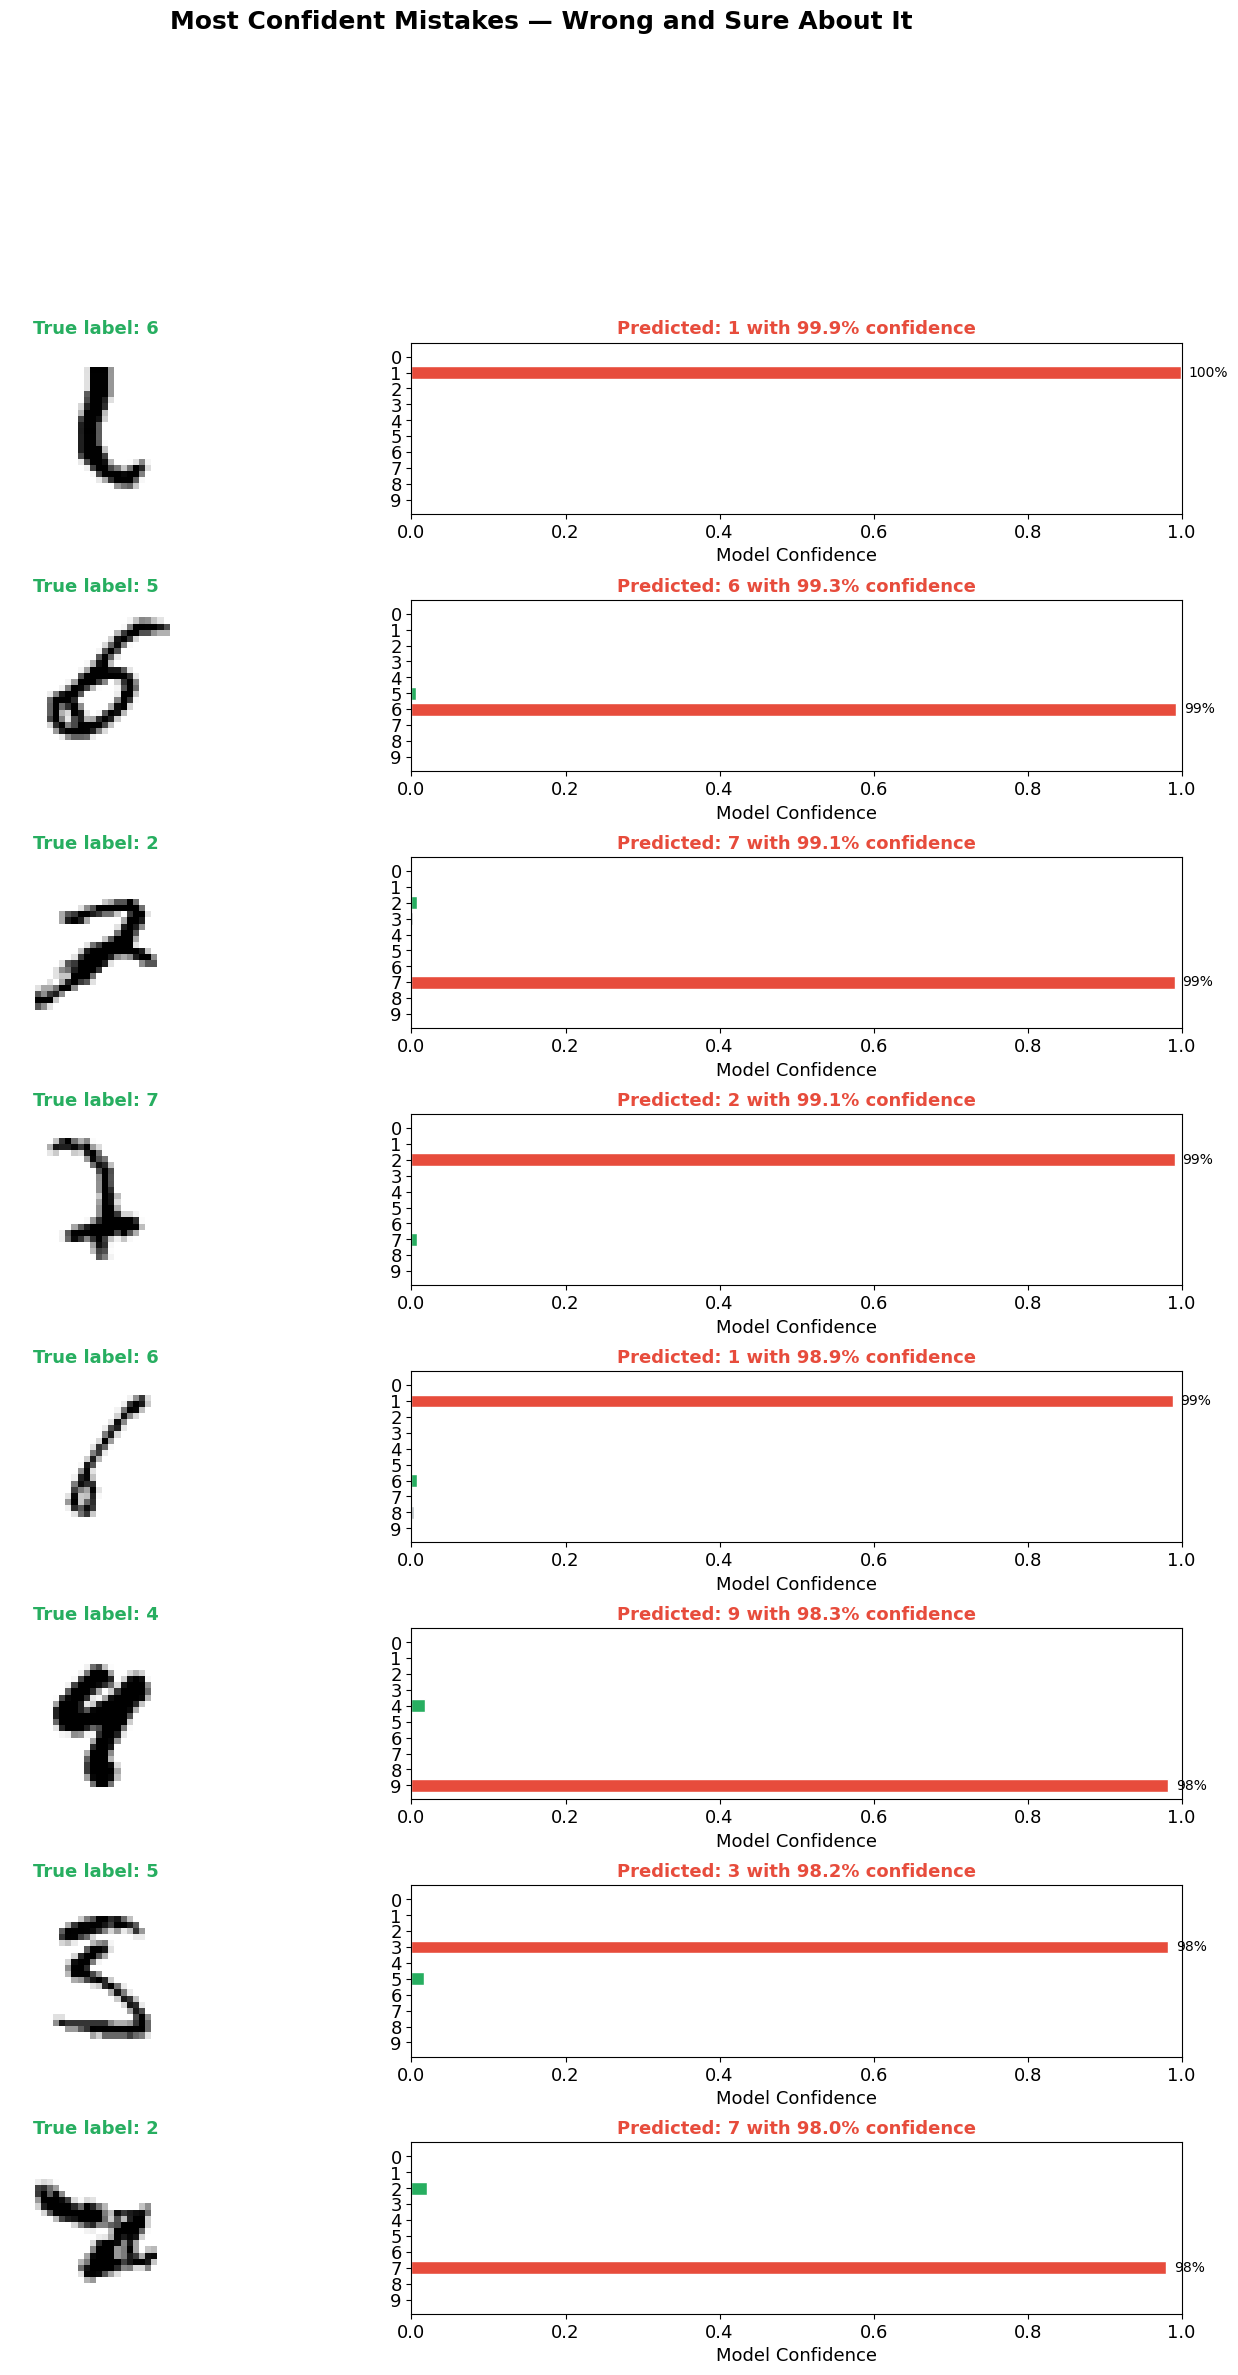


Look at these. Obvious to any human. Wrong and certain about it.
The model has no mechanism for saying 'I don't know'.


In [9]:
def plot_confident_mistakes(indices, x_data, y_true, preds, n=8):
    """Show the most confident wrong predictions with confidence bar charts."""
    n = min(n, len(indices))
    fig = plt.figure(figsize=(16, 3.2 * n))
    fig.suptitle(
        "Most Confident Mistakes — Wrong and Sure About It",
        fontsize=18, fontweight='bold', y=1.01
    )

    gs = gridspec.GridSpec(n, 2, width_ratios=[1, 2.5], hspace=0.5, wspace=0.3)

    digit_names = [str(d) for d in range(10)]

    for row in range(n):
        idx = indices[row]
        true_label = y_true[idx]
        pred_probs = preds[idx]
        pred_label = np.argmax(pred_probs)
        pred_conf = pred_probs[pred_label]

        # Left: the digit image
        ax_img = fig.add_subplot(gs[row, 0])
        ax_img.imshow(x_data[idx], cmap='gray_r')
        ax_img.set_title(
            f"True label: {true_label}",
            fontsize=13, fontweight='bold', color='#27ae60'
        )
        ax_img.axis('off')

        # Right: confidence bar chart
        ax_bar = fig.add_subplot(gs[row, 1])
        colours = []
        for d in range(10):
            if d == pred_label:
                colours.append('#e74c3c')  # red for wrong prediction
            elif d == true_label:
                colours.append('#27ae60')  # green for true label
            else:
                colours.append('#bdc3c7')  # grey for others

        bars = ax_bar.barh(digit_names, pred_probs, color=colours, edgecolor='white')
        ax_bar.set_xlim(0, 1)
        ax_bar.set_xlabel('Model Confidence')
        ax_bar.set_title(
            f'Predicted: {pred_label} with {pred_conf:.1%} confidence',
            fontsize=13, fontweight='bold', color='#e74c3c'
        )
        ax_bar.invert_yaxis()

        # Add percentage labels on bars
        for d, prob in enumerate(pred_probs):
            if prob > 0.02:
                ax_bar.text(prob + 0.01, d, f'{prob:.0%}', va='center', fontsize=10)

    plt.savefig('outputs/mnist_confident_mistakes.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_confident_mistakes(wrong_indices_sorted, x_test, y_test, predictions, n=8)

print("\nLook at these. Obvious to any human. Wrong and certain about it.")
print("The model has no mechanism for saying 'I don't know'.")

## 7. The Confidence Distribution

Let's compare how confident the model is when it's right vs. when it's wrong. You'd hope that wrong predictions come with low confidence — but that's not always the case.

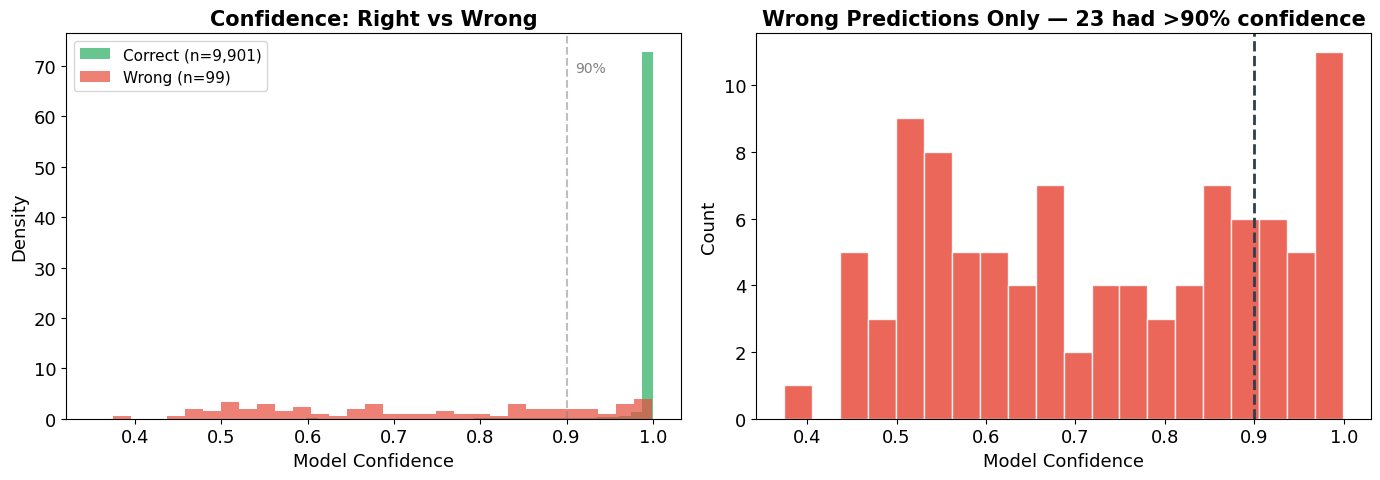


23 wrong predictions had >90% confidence.
The model doesn't know what it doesn't know.


In [10]:
correct_confidences = confidence_scores[~wrong_mask]
wrong_confidences_all = confidence_scores[wrong_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram comparison
axes[0].hist(correct_confidences, bins=50, alpha=0.7, color='#27ae60',
             label=f'Correct (n={len(correct_confidences):,})', density=True)
axes[0].hist(wrong_confidences_all, bins=30, alpha=0.7, color='#e74c3c',
             label=f'Wrong (n={len(wrong_confidences_all)})', density=True)
axes[0].set_xlabel('Model Confidence')
axes[0].set_ylabel('Density')
axes[0].set_title('Confidence: Right vs Wrong', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].axvline(x=0.9, color='gray', linestyle='--', alpha=0.5)
axes[0].text(0.91, axes[0].get_ylim()[1] * 0.9, '90%', color='gray', fontsize=10)

# Right: focus on wrong predictions
high_conf_wrong = (wrong_confidences_all > 0.9).sum()
axes[1].hist(wrong_confidences_all, bins=20, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Model Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title(
    f'Wrong Predictions Only — {high_conf_wrong} had >90% confidence',
    fontweight='bold'
)
axes[1].axvline(x=0.9, color='#2c3e50', linestyle='--', linewidth=2)

plt.tight_layout()
plt.savefig('outputs/mnist_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{high_conf_wrong} wrong predictions had >90% confidence.")
print(f"The model doesn't know what it doesn't know.")

## 8. Confusion Matrix — Where Does It Go Wrong?

Which digits does the model confuse with each other? This tells us something about *how* it fails — it confuses digits that share visual features (5s and 3s, 4s and 9s, 7s and 2s).

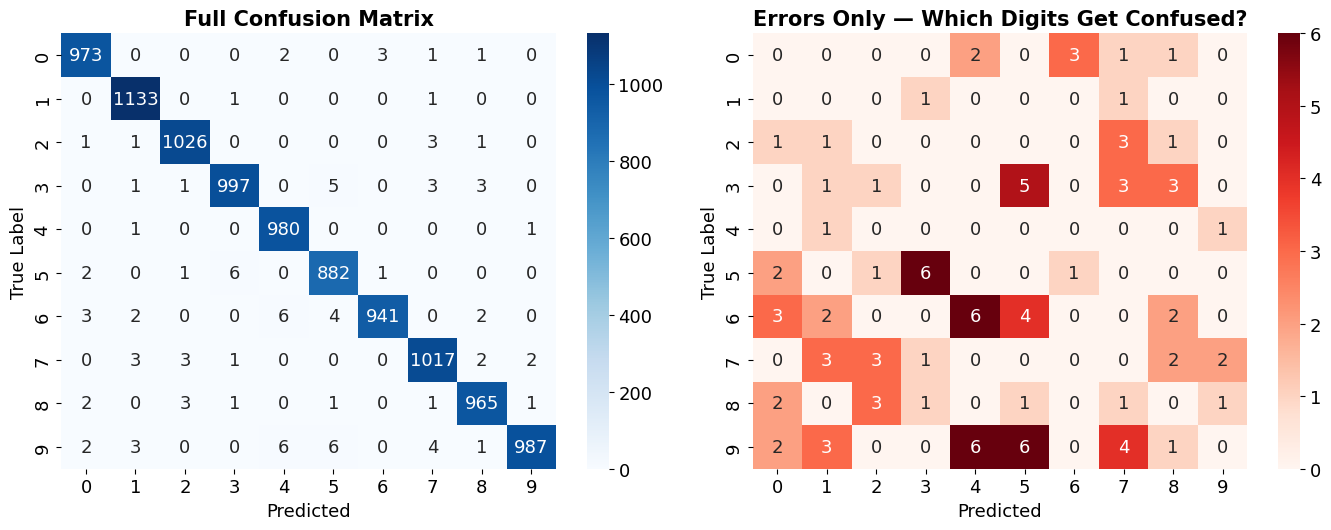


Top confusions:
  9 mistaken for 5: 6 times
  9 mistaken for 4: 6 times
  6 mistaken for 4: 6 times
  5 mistaken for 3: 6 times
  3 mistaken for 5: 5 times


In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Build confusion matrix (only wrong predictions for clarity)
cm = confusion_matrix(y_test, predicted_labels)

# Zero out the diagonal to focus on errors
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Full confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Label')
axes[0].set_title('Full Confusion Matrix', fontweight='bold')

# Errors only
sns.heatmap(cm_errors, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True Label')
axes[1].set_title('Errors Only — Which Digits Get Confused?', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/mnist_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Find the top confusions
top_confusions = []
for i in range(10):
    for j in range(10):
        if i != j and cm_errors[i, j] > 0:
            top_confusions.append((cm_errors[i, j], i, j))

top_confusions.sort(reverse=True)
print("\nTop confusions:")
for count, true, pred in top_confusions[:5]:
    print(f"  {true} mistaken for {pred}: {count} times")

## 9. The Adversarial Fragility

Here's something even more unsettling. If we add tiny amounts of random noise — invisible to the human eye — the model's accuracy drops dramatically. The patterns it learned are *brittle*.

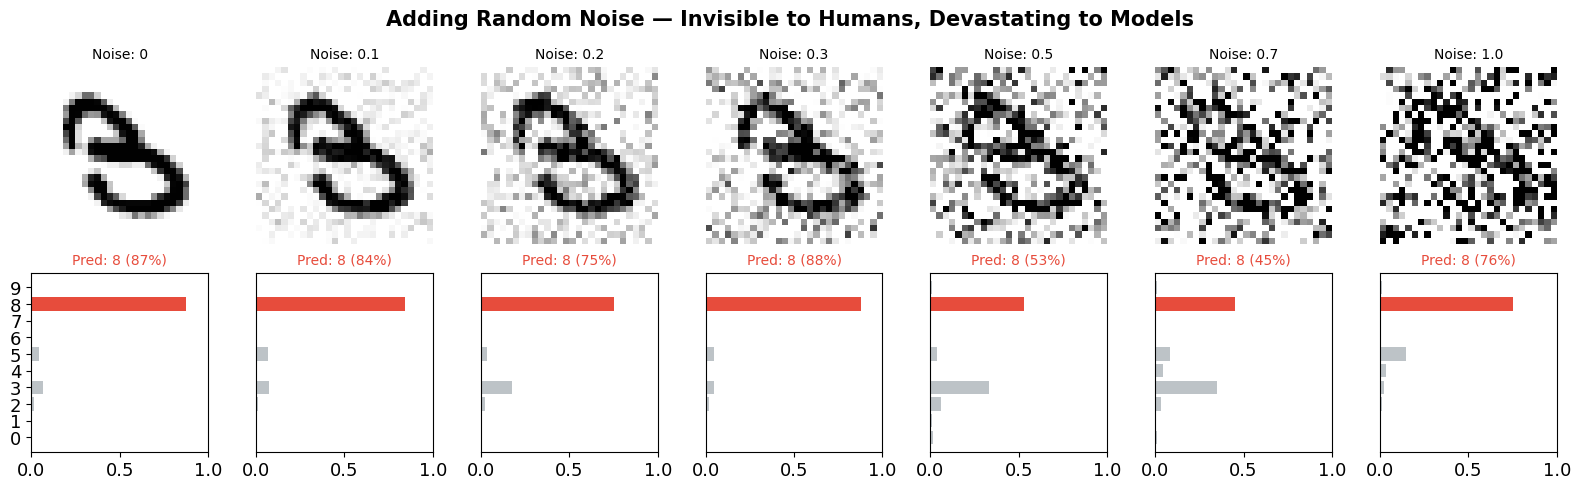

In [12]:
noise_levels = [0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
accuracies = []
avg_confidences = []

# Pick one example to show visually
example_idx = np.where(y_test == 3)[0][0]  # Find a "3"

fig, axes = plt.subplots(2, len(noise_levels), figsize=(16, 5))
fig.suptitle('Adding Random Noise — Invisible to Humans, Devastating to Models',
             fontsize=15, fontweight='bold')

for col, noise in enumerate(noise_levels):
    # Add noise
    noisy_data = x_test_norm + noise * np.random.randn(*x_test_norm.shape).astype('float32')
    noisy_data = np.clip(noisy_data, 0, 1)

    # Evaluate
    noisy_preds = model.predict(noisy_data, verbose=0)
    noisy_labels = np.argmax(noisy_preds, axis=1)
    acc = (noisy_labels == y_test).mean()
    avg_conf = np.max(noisy_preds, axis=1).mean()
    accuracies.append(acc)
    avg_confidences.append(avg_conf)

    # Show example image
    axes[0, col].imshow(noisy_data[example_idx, :, :, 0], cmap='gray_r')
    axes[0, col].set_title(f'Noise: {noise}', fontsize=10)
    axes[0, col].axis('off')

    # Show confidence for this example
    pred_label = noisy_labels[example_idx]
    pred_conf = noisy_preds[example_idx, pred_label]
    colour = '#27ae60' if pred_label == y_test[example_idx] else '#e74c3c'
    axes[1, col].barh(range(10), noisy_preds[example_idx], color='#bdc3c7')
    axes[1, col].barh(pred_label, noisy_preds[example_idx, pred_label], color=colour)
    axes[1, col].set_title(f'Pred: {pred_label} ({pred_conf:.0%})', fontsize=10, color=colour)
    axes[1, col].set_xlim(0, 1)
    if col == 0:
        axes[1, col].set_yticks(range(10))
    else:
        axes[1, col].set_yticks([])

plt.tight_layout()
plt.savefig('outputs/mnist_noise_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

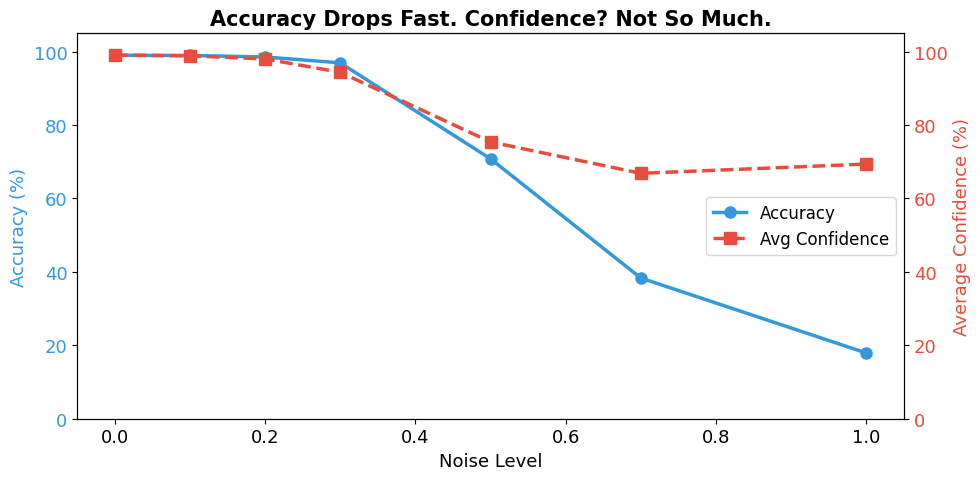


At noise level 0.5:
  Accuracy dropped to 70.8%
  But average confidence is still 75.4%

The model is getting worse, but it doesn't know it's getting worse.


In [13]:
# Accuracy vs noise level
fig, ax1 = plt.subplots(figsize=(10, 5))

colour1 = '#3498db'
colour2 = '#e74c3c'

ax1.plot(noise_levels, [a * 100 for a in accuracies], 'o-',
         color=colour1, linewidth=2.5, markersize=8, label='Accuracy')
ax1.set_xlabel('Noise Level', fontsize=13)
ax1.set_ylabel('Accuracy (%)', color=colour1, fontsize=13)
ax1.tick_params(axis='y', labelcolor=colour1)
ax1.set_ylim(0, 105)

ax2 = ax1.twinx()
ax2.plot(noise_levels, [c * 100 for c in avg_confidences], 's--',
         color=colour2, linewidth=2.5, markersize=8, label='Avg Confidence')
ax2.set_ylabel('Average Confidence (%)', color=colour2, fontsize=13)
ax2.tick_params(axis='y', labelcolor=colour2)
ax2.set_ylim(0, 105)

plt.title('Accuracy Drops Fast. Confidence? Not So Much.',
          fontsize=15, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/mnist_accuracy_vs_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAt noise level 0.5:")
print(f"  Accuracy dropped to {accuracies[4]:.1%}")
print(f"  But average confidence is still {avg_confidences[4]:.1%}")
print(f"\nThe model is getting worse, but it doesn't know it's getting worse.")

## 10. So What?

This was the **simplest possible task** in machine learning:
- Clean, human-labelled data
- Only 10 categories
- No ambiguity in the ground truth
- A well-understood, textbook model

And yet:
- The model makes **confident mistakes** — wrong with 95%+ certainty
- It has **no mechanism** for saying "I don't know"
- Tiny perturbations **destroy** its performance while it remains confident
- It confuses things that **look nothing alike** to a human

Now scale this up to language — where the data is noisy, the task is ambiguous, and the "right answer" is often a matter of opinion.

**That's what you're using when you use ChatGPT, Claude, or any LLM.**

The same fundamental architecture. The same structural inability to say "I'm not sure." Just much, much bigger.